# A Retail Decision-Support Workflow for Supermarkets: Product-Line Priorities and Branch-Level Differences


## 1. Project Introduction

This project builds a Python-based decision-support workflow for supermarket transaction data. The current notebook uses `supermarket.xlsx` as a sample dataset, but the workflow is designed to be reusable for similar retail datasets such as POS exports, CSV sales reports, or ERP data extracts.

The main goal is not only to describe the data, but also to help managers identify product-line priorities and branch-level differences. The analysis focuses on sales performance, gross income contribution, concentration of key product lines, and differences across branches. In addition, the notebook includes a data standard and module detection structure, so that the same workflow can be reused and extended when future datasets contain more fields such as discounts, inventory, customer ID, or store-operation indicators.

### Business Question

Which product lines should managers prioritise, and do different branches require different product-line strategies based on sales, income, concentration, and branch-level patterns?


## 2. Executive Summary

This notebook demonstrates a reusable retail decision-support workflow using a sample supermarket transaction dataset.

### Activated modules in the current sample
- Sales Overview
- Product-Line Priority Analysis
- Sales and Income Quality Analysis
- Concentration Analysis
- Branch-Level Performance Analysis
- Customer Analysis
- Time Pattern Analysis
- Relationship / Factor Analysis

### Most important findings from the current sample
- `Food and beverages` is the strongest product line overall in both total sales and gross income.
- Sales and gross income are concentrated in a relatively small number of product lines.
- Branch-level results show that the strongest product lines are not identical across all branches.
- Branch-level sales concentration suggests that each branch depends meaningfully on a limited number of categories.

### Immediate managerial implications
- Managers should give higher priority to product lines that are strong in both sales and gross income.
- Company-wide product priorities are useful, but branch-level adjustment is still necessary.
- Concentration should be monitored because strong dependence on a small set of categories increases strategic sensitivity.


## 3. User Guide and Output Navigation

The notebook is organised so that non-technical users can first read the summary and recommendations, while technical users can inspect the detailed code, data checks, and intermediate outputs.

### How to use this notebook
1. Set the parameter values in the loading section.
2. Provide a structured retail transaction dataset.
3. Run the notebook from top to bottom.
4. Review the rename report, schema detection results, and module status table.
5. Read the executive summary for a quick overview.
6. Use the core analysis sections to explore detailed results.
7. Review the final recommendations and key takeaways.

### What this notebook can output
Depending on the available fields, the notebook can produce:
- Sales overview summaries
- Product-line priority rankings
- Sales and gross-income comparisons
- Concentration analysis
- Branch-level comparisons
- Customer-level summaries
- Time-based patterns
- Relationship and factor summaries

### Navigation map
- Section 2: Quick result summary for managers
- Section 4: Input data requirements
- Section 5: Parameter setup, file loading, and schema detection
- Section 6: Feature engineering and reusable workflow functions
- Section 7: Core analysis outputs
- Section 9: Recommendations
- Section 10: Final summary for decision-makers

### Current module status in this sample
All core manager-facing modules are active in the current demonstration dataset, while some richer extensions remain inactive because the sample does not include discount, inventory, or customer-ID fields.


## 4. Data Standard and Submission Guide

This workflow is designed to work with structured retail transaction data. To improve reusability, input data should follow a clear submission standard.

### Required fields
The following fields are required for the core decision-support workflow:
- product category / product line
- branch / store identifier
- sales value
- income / profit-related value
- date

### Recommended fields
These fields improve analytical depth:
- quantity
- customer type
- payment method
- time of transaction
- rating / feedback
- city / location

### Optional fields
These fields support future extensions:
- promotion / discount
- inventory
- customer ID
- foot traffic
- supplier or cost details

### Supported file formats
- `.xlsx`
- `.csv`

### Standard upload mode
In standard upload mode, the input file already follows expected field names or near-equivalent field names.

### Assisted mapping mode
In assisted mapping mode, the user provides a dataset with different column names, and the workflow maps available fields to required analytical roles.

### Internal standard field names
After loading, the workflow standardises mapped columns to internal names such as `sales`, `gross_income`, `product_line`, `branch`, and `date`. This makes later analysis more reusable and less dependent on one specific spreadsheet format.

### Standard Field Dictionary

The table below summarises the standard fields supported by this template. It is designed to help managers or analysts prepare a standard-format dataset before running the workflow.

| Standard Field | Meaning | Required Level | Example | Accepted Aliases |
|---|---|---|---|---|
| sales | Transaction revenue or total paid amount | Required | 548.97 | Total, Sales, Revenue |
| product_line | Product category or department | Required | Food and beverages | Product line, Category, Department |
| gross_income | Gross profit generated by the transaction | Recommended | 26.14 | Gross Income, Gross Profit, Profit |
| branch | Store or branch identifier | Recommended | A | Branch, Store, Outlet |
| date | Transaction date | Recommended | 2019-01-05 | Date, Transaction Date |
| time | Transaction time | Recommended | 13:45 | Time, Transaction Time |
| quantity | Number of units sold | Recommended | 7 | Quantity, Qty, Units |
| unit_price | Selling price per unit | Recommended | 74.69 | Unit Price, Price |
| customer_type | Customer segment or membership type | Optional | Member | Customer Type, Segment |
| payment | Payment method | Optional | Ewallet | Payment, Payment Method |
| rating | Customer rating or score | Optional | 9.1 | Rating, Review Score |
| city | Store city or location | Optional | Yangon | City, Region, Location |
| discount | Discount amount or rate | Extended | 0.10 | Discount, Markdown |
| promotion_flag | Whether a promotion was applied | Extended | Yes | Promotion, Promo Flag |
| inventory_level | Current stock level | Extended | 85 | Inventory, Stock Level |
| stockout_flag | Whether the item was out of stock | Extended | No | Stockout, Out of Stock |
| customer_id | Unique customer identifier | Extended | C1025 | Customer ID, Member ID |
| foot_traffic | Number of visitors | Extended | 320 | Foot Traffic, Store Traffic |
| store_size | Store size or area | Extended | 1200 | Store Size, Area |
| staff_count | Number of staff in store | Extended | 18 | Staff Count, Employees |

### Current demonstration input
The current notebook uses a sample Excel file with fields such as `Product line`, `Branch`, `Total`, `gross income`, and `Date`.


## 5. Data Loading and Schema Detection

This section loads the input data, applies parameter settings, standardises the input structure, and identifies which analytical modules can be activated based on the available fields. The goal is to make the notebook easier to rerun on future retail datasets without rewriting the main analysis logic.

**Source:** Kaggle supermarket sales dataset (used here as a sample demonstration input).
**Accessed:** 2026-04-20

In [1]:
from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format
plt.style.use("seaborn-v0_8-whitegrid")

primary_color = "#2F6B5B"
secondary_color = "#6AA38E"
accent_color = "#D98B5F"
branch_colors = ["#2F6B5B", "#6AA38E", "#D9B26F"]


In [2]:
# Reusable data-loading function
def load_data(file_path, sheet_name=0):
    """Load a retail dataset from Excel or CSV using a relative path."""
    if file_path.endswith(".xlsx"):
        return pd.read_excel(file_path, sheet_name=sheet_name)
    elif file_path.endswith(".csv"):
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format. Please use .xlsx or .csv")


In [3]:
# Parameters
FILE_PATH = "supermarket.xlsx"
SHEET_NAME = 0
TOP_N = 5

# Load dataset
df = load_data(FILE_PATH, sheet_name=SHEET_NAME)
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08:00,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29:00,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23:00,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33:00,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37:00,Ewallet,604.17,4.76,30.21,5.30


In [4]:
STANDARD_FIELDS = [
    "sales",
    "gross_income",
    "product_line",
    "branch",
    "date",
    "time",
    "quantity",
    "unit_price",
    "customer_type",
    "payment",
    "rating",
    "city",
]

ALIASES = {
    "sales": ["total", "sales", "revenue", "net sales"],
    "gross_income": ["gross income", "gross profit", "profit", "income"],
    "product_line": ["product line", "category", "department"],
    "branch": ["branch", "store", "outlet"],
    "date": ["date", "transaction date"],
    "time": ["time", "transaction time"],
    "quantity": ["quantity", "qty", "units"],
    "unit_price": ["unit price", "price", "selling price"],
    "customer_type": ["customer type", "member type", "segment"],
    "payment": ["payment", "payment method"],
    "rating": ["rating", "customer rating", "review score"],
    "city": ["city", "location", "region"],
    "cogs": ["cogs", "cost of goods sold"],
    "gender": ["gender"],
    "discount": ["discount", "promotion discount"],
    "inventory_level": ["inventory", "inventory level", "stock level"],
}


def standardize_columns(df, aliases):
    """
    Standardise column names using a field alias dictionary.
    Returns the updated dataframe and a rename report.
    """
    df = df.copy()
    original_columns = list(df.columns)

    cleaned_columns = {
        col: col.strip().lower()
        for col in df.columns
    }
    df = df.rename(columns=cleaned_columns)

    rename_map = {}
    for standard_name, alias_list in aliases.items():
        for alias in alias_list:
            if alias in df.columns:
                rename_map[alias] = standard_name
                break

    df = df.rename(columns=rename_map)

    rename_report = pd.DataFrame({
        "original_column": original_columns,
        "cleaned_column": [col.strip().lower() for col in original_columns],
    })

    rename_report["standardised_to"] = rename_report["cleaned_column"].map(rename_map)
    return df, rename_report


df, rename_report = standardize_columns(df, ALIASES)
display(rename_report)
df.head()


,original_column,cleaned_column,standardised_to
0,Invoice ID,invoice id,NaN
1,Branch,branch,branch
2,City,city,city
3,Customer type,customer type,customer_type
4,Gender,gender,gender
5,Product line,product line,product_line
6,Unit price,unit price,unit_price
7,Quantity,quantity,quantity
8,Tax 5%,tax 5%,NaN
9,Total,total,sales


,invoice id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax 5%,sales,date,time,payment,cogs,gross margin percentage,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,13:08:00,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,10:29:00,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,13:23:00,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,2019-01-27,20:33:00,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2019-02-08,10:37:00,Ewallet,604.17,4.76,30.21,5.30


### Current Demonstration Dataset

The current demonstration dataset contains 1,000 transaction records and 17 variables. After standardisation, the main working fields become names such as `sales`, `gross_income`, `product_line`, `branch`, and `date`.


### Initial Inspection

Before moving into deeper analysis, the dataset is checked for its shape, column names, data types, and missing values. This helps confirm that the current file is usable and also makes the workflow more transparent for future reuse with other retail inputs.


In [5]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names after standardisation:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values:")
print(df.isna().sum())


Shape of the dataset:
(1000, 17)

Column names after standardisation:
['invoice id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax 5%', 'sales', 'date', 'time', 'payment', 'cogs', 'gross margin percentage', 'gross_income', 'rating']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice id               1000 non-null   object        
 1   branch                   1000 non-null   object        
 2   city                     1000 non-null   object        
 3   customer_type            1000 non-null   object        
 4   gender                   1000 non-null   object        
 5   product_line             1000 non-null   object        
 6   unit_price               1000 non-null   float64       
 7   quantity                 100

In [6]:
available_columns = set(df.columns)

required_for_core = {
    "product_line", "branch", "sales", "gross_income", "date"
}

recommended_fields = {
    "quantity", "customer_type", "payment", "time", "rating", "city"
}

core_ready = required_for_core.issubset(available_columns)
available_recommended = sorted(list(available_columns.intersection(recommended_fields)))

print("Core workflow ready:", core_ready)
print("Available recommended fields:", available_recommended)
print("All available columns:", sorted(list(available_columns)))


Core workflow ready: True
Available recommended fields: ['city', 'customer_type', 'payment', 'quantity', 'rating', 'time']
All available columns: ['branch', 'city', 'cogs', 'customer_type', 'date', 'gender', 'gross margin percentage', 'gross_income', 'invoice id', 'payment', 'product_line', 'quantity', 'rating', 'sales', 'tax 5%', 'time', 'unit_price']


In [7]:
MODULE_REQUIREMENTS = {
    "Sales Overview": ["sales"],
    "Product-Line Priority Analysis": ["product_line", "sales"],
    "Sales and Income Quality Analysis": ["product_line", "sales", "gross_income"],
    "Branch-Level Performance Analysis": ["branch", "sales"],
    "Customer Segment Analysis": ["customer_type"],
    "Time Pattern Analysis": ["date"],
    "Relationship / Factor Analysis": ["sales", "gross_income"],
    "Promotion Analysis": ["discount"],
    "Inventory Analysis": ["inventory_level"],
}


#This function automatically verifies the dataset fields, determines whether each analysis module meets the running conditions, and generates a visual result table.
def detect_available_features(df, module_requirements):
    """
    Detect which analysis modules can be activated based on available fields.
    """
    available_columns = set(df.columns)
    records = []

    for module_name, required_fields in module_requirements.items():
        missing_fields = [field for field in required_fields if field not in available_columns]
        status = "Activated" if not missing_fields else "Not activated"
        records.append({
            "module": module_name,
            "status": status,
            "required_fields": ", ".join(required_fields),
            "missing_fields": ", ".join(missing_fields) if missing_fields else "-",
        })

    return pd.DataFrame(records)


module_status = detect_available_features(df, MODULE_REQUIREMENTS)
activated_modules = module_status.loc[module_status["status"] == "Activated", "module"].tolist()
display(module_status)


,module,status,required_fields,missing_fields
0,Sales Overview,Activated,sales,-
1,Product-Line Priority Analysis,Activated,"product_line, sales",-
2,Sales and Income Quality Analysis,Activated,"product_line, sales, gross_income",-
3,Branch-Level Performance Analysis,Activated,"branch, sales",-
4,Customer Segment Analysis,Activated,customer_type,-
5,Time Pattern Analysis,Activated,date,-
6,Relationship / Factor Analysis,Activated,"sales, gross_income",-
7,Promotion Analysis,Not activated,discount,discount
8,Inventory Analysis,Not activated,inventory_level,inventory_level


The module status table acts as a quick control panel. Managers and markers can immediately see which parts of the template are active and which future extensions would need richer fields.


## 6. Data Cleaning and Feature Engineering

This section prepares the input data for later analysis. The current sample requires only light preparation, but the workflow still adds a few derived variables so that time analysis, operational interpretation, and factor analysis are better supported. In richer datasets, this section could be extended further.


In [8]:
df = df.copy()

# Date conversion
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["month"] = df["date"].dt.month
    df["weekday"] = df["date"].dt.day_name()
    df["weekend_flag"] = df["date"].dt.dayofweek >= 5

# Time conversion
if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce")
    df["hour"] = df["time"].dt.hour

    def classify_part_of_day(hour):
        if pd.isna(hour):
            return "Unknown"
        elif hour < 12:
            return "Morning"
        elif hour < 18:
            return "Afternoon"
        else:
            return "Evening"

    df["part_of_day"] = df["hour"].apply(classify_part_of_day)

# Income efficiency
if "gross_income" in df.columns and "sales" in df.columns:
    df["gross_income_ratio"] = df["gross_income"] / df["sales"].replace({0: pd.NA})

# Check key numeric columns that are available in the current input
numeric_columns = [
    col for col in [
        "sales", "gross_income", "quantity", "rating", "unit_price", "cogs", "gross_income_ratio"
    ]
    if col in df.columns
]

derived_features = [
    col for col in [
        "month", "weekday", "weekend_flag", "hour", "part_of_day", "gross_income_ratio"
    ]
    if col in df.columns
]

print("Derived features created:", derived_features)
df[numeric_columns].describe()


Derived features created: ['month', 'weekday', 'weekend_flag', 'hour', 'part_of_day', 'gross_income_ratio']


,sales,gross_income,quantity,rating,unit_price,cogs,gross_income_ratio
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,322.97,15.38,5.51,6.97,55.67,307.59,0.05
std,245.89,11.71,2.92,1.72,26.49,234.18,0.00
min,10.68,0.51,1.00,4.00,10.08,10.17,0.05
25%,124.42,5.92,3.00,5.50,32.88,118.50,0.05
50%,253.85,12.09,5.00,7.00,55.23,241.76,0.05
75%,471.35,22.45,8.00,8.50,77.94,448.91,0.05
max,"1,042.65",49.65,10.00,10.00,99.96,993.00,0.05


In [9]:
# Recheck the missing values
df.isna().sum()

invoice id                    0
branch                        0
city                          0
customer_type                 0
gender                        0
product_line                  0
unit_price                    0
quantity                      0
tax 5%                        0
sales                         0
date                          0
time                       1000
payment                       0
cogs                          0
gross margin percentage       0
gross_income                  0
rating                        0
month                         0
weekday                       0
weekend_flag                  0
hour                       1000
part_of_day                   0
gross_income_ratio            0
dtype: int64

In [10]:
if "date" in df.columns:
    pd.DataFrame({
        "metric": ["start_date", "end_date"],
        "value": [df["date"].min(), df["date"].max()],
    })
else:
    print("No date field is available for time coverage review.")


### Cleaning Summary

The workflow standardised source columns, converted the `date` field, created time-based variables such as `month`, `weekday`, `weekend_flag`, `hour`, and `part_of_day`, and added `gross_income_ratio` as a simple income-efficiency feature. In the current sample, these additions mainly strengthen time and factor analysis. In richer retail datasets, the same section could be extended with promotion, margin, inventory, or customer-history features.


 ### Reusable Workflow Functions

All core analytical calculations are encapsulated into independent, reusable functions. These modules handle sales overview, product-line performance, branch comparison and other key metrics. Subsequent analysis directly calls these functions, simplifying code structure and enabling the workflow to adapt to new retail datasets efficiently.


In [11]:

def calculate_top_n_share(summary_df, metric_col, n=3):
    total_value = summary_df[metric_col].sum()
    top_n_value = summary_df.head(n)[metric_col].sum()
    return top_n_value / total_value


def run_sales_overview(df):
    result = {}

    if "sales" in df.columns:
        result["total_sales"] = df["sales"].sum()
        result["average_sales"] = df["sales"].mean()
        result["transaction_count"] = df["sales"].count()

    if "gross_income" in df.columns:
        result["total_gross_income"] = df["gross_income"].sum()
        result["average_gross_income"] = df["gross_income"].mean()

    if "quantity" in df.columns:
        result["total_quantity"] = df["quantity"].sum()
        result["average_quantity"] = df["quantity"].mean()

    if "rating" in df.columns:
        result["average_rating"] = df["rating"].mean()

    return pd.DataFrame(result, index=[0])


def run_product_line_analysis(df):
    aggregations = {
        "sales": ("sales", "sum"),
    }
    if "gross_income" in df.columns:
        aggregations["gross_income"] = ("gross_income", "sum")
    if "quantity" in df.columns:
        aggregations["quantity"] = ("quantity", "sum")

    result = (
        df.groupby("product_line")
        .agg(**aggregations)
        .sort_values("sales", ascending=False)
        .reset_index()
    )
    return result


def run_branch_analysis(df):
    aggregations = {
        "sales": ("sales", "sum"),
    }
    if "gross_income" in df.columns:
        aggregations["gross_income"] = ("gross_income", "sum")
    if "quantity" in df.columns:
        aggregations["quantity"] = ("quantity", "sum")

    result = (
        df.groupby("branch")
        .agg(**aggregations)
        .sort_values("sales", ascending=False)
        .reset_index()
    )
    return result


def run_customer_analysis(df):
    if "customer_type" not in df.columns:
        return None

    aggregations = {
        "average_sales": ("sales", "mean"),
        "transaction_count": ("sales", "count"),
    }
    if "gross_income" in df.columns:
        aggregations["average_gross_income"] = ("gross_income", "mean")
    if "rating" in df.columns:
        aggregations["average_rating"] = ("rating", "mean")

    result = (
        df.groupby("customer_type")
        .agg(**aggregations)
        .sort_values("average_sales", ascending=False)
        .reset_index()
    )
    return result


def run_time_analysis(df):
    if "weekday" not in df.columns:
        return None

    aggregations = {
        "sales": ("sales", "sum"),
    }
    if "gross_income" in df.columns:
        aggregations["gross_income"] = ("gross_income", "sum")

    result = df.groupby("weekday").agg(**aggregations).reset_index()
    return result


def grouped_factor_summary(df, group_col):
    aggregations = {
        "average_sales": ("sales", "mean"),
        "transaction_count": ("sales", "count"),
    }
    if "gross_income" in df.columns:
        aggregations["average_gross_income"] = ("gross_income", "mean")

    summary = (
        df.groupby(group_col)
        .agg(**aggregations)
        .sort_values("average_sales", ascending=False)
        .reset_index()
    )
    return summary


## 7. Core Decision-Support Analysis

This section turns the cleaned dataset into decision-support outputs. The analysis focuses on identifying which product lines should receive priority attention, whether sales and gross income are concentrated in a small number of categories, and whether different branches show different product-line patterns. These outputs are used later to support clear business recommendations.

### 7.1 Sales Overview

This table gives a quick first look at the supermarket sample. It summarises the total sales scale, average transaction value, total gross income, total quantity sold, and average customer rating before moving into product-line and branch-level analysis.

In [12]:
sales_overview = run_sales_overview(df)

print("Sales overview:")
display(sales_overview)


Sales overview:


,total_sales,average_sales,transaction_count,total_gross_income,average_gross_income,total_quantity,average_quantity,average_rating
0,"322,966.75",322.97,1000,"15,379.37",15.38,5510,5.51,6.97


The results confirm the sample contains 1,000 transactions, with average sales per transaction at  322.97 and total gross income of 15,379.37. This provides a solid reference for evaluating performance across different categories and branches.


### 7.2 Product-Line Priority Analysis

This section compares product lines using both total sales and gross income. Looking at the two measures together gives a better sense of which lines matter most commercially, rather than relying on sales alone.


In [13]:
product_line_summary = run_product_line_analysis(df)

product_sales = (
    product_line_summary[["product_line", "sales"]]
    .sort_values("sales", ascending=False)
    .reset_index(drop=True)
)

product_income = (
    product_line_summary[["product_line", "gross_income"]]
    .sort_values("gross_income", ascending=False)
    .reset_index(drop=True)
)

product_summary = product_line_summary.copy()
product_summary["sales_share"] = product_summary["sales"] / product_summary["sales"].sum()
product_summary["income_share"] = (
    product_summary["gross_income"] / product_summary["gross_income"].sum()
)

product_summary


,product_line,sales,gross_income,quantity,sales_share,income_share
0,Food and beverages,"56,144.84","2,673.56",952,0.17,0.17
1,Sports and travel,"55,122.83","2,624.90",920,0.17,0.17
2,Electronic accessories,"54,337.53","2,587.50",971,0.17,0.17
3,Fashion accessories,"54,305.89","2,585.99",902,0.17,0.17
4,Home and lifestyle,"53,861.91","2,564.85",911,0.17,0.17
5,Health and beauty,"49,193.74","2,342.56",854,0.15,0.15


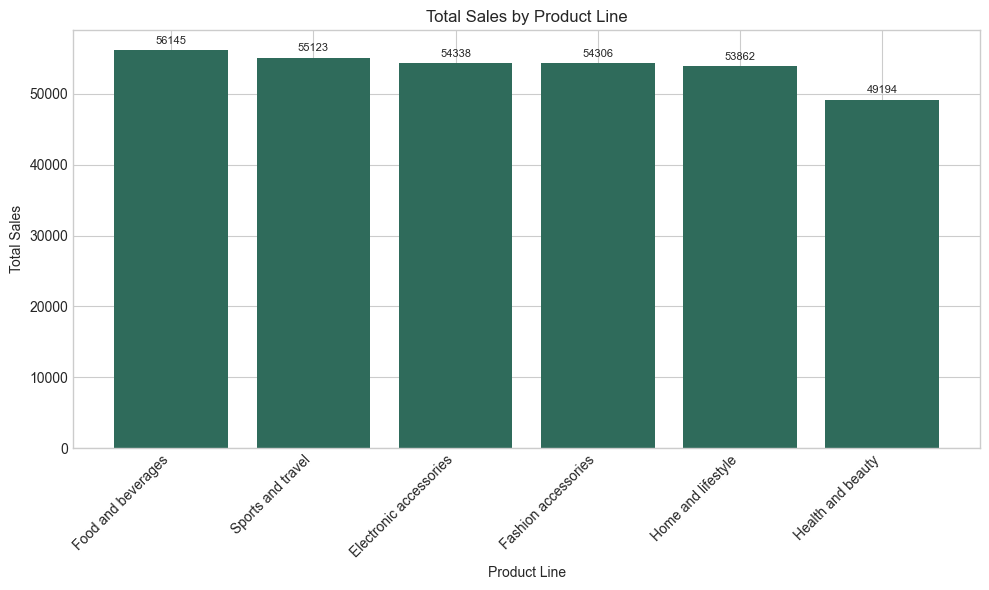

In [14]:
plt.figure(figsize=(10, 6))
bars = plt.bar(product_sales["product_line"], product_sales["sales"], color=primary_color)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product Line")
plt.gca().bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()


The sales chart shows that product-line performance is not evenly distributed. A small number of categories generate relatively higher sales, which supports a prioritisation-based approach instead of treating all product lines as equally important.

In [15]:
product_income


,product_line,gross_income
0,Food and beverages,"2,673.56"
1,Sports and travel,"2,624.90"
2,Electronic accessories,"2,587.50"
3,Fashion accessories,"2,585.99"
4,Home and lifestyle,"2,564.85"
5,Health and beauty,"2,342.56"


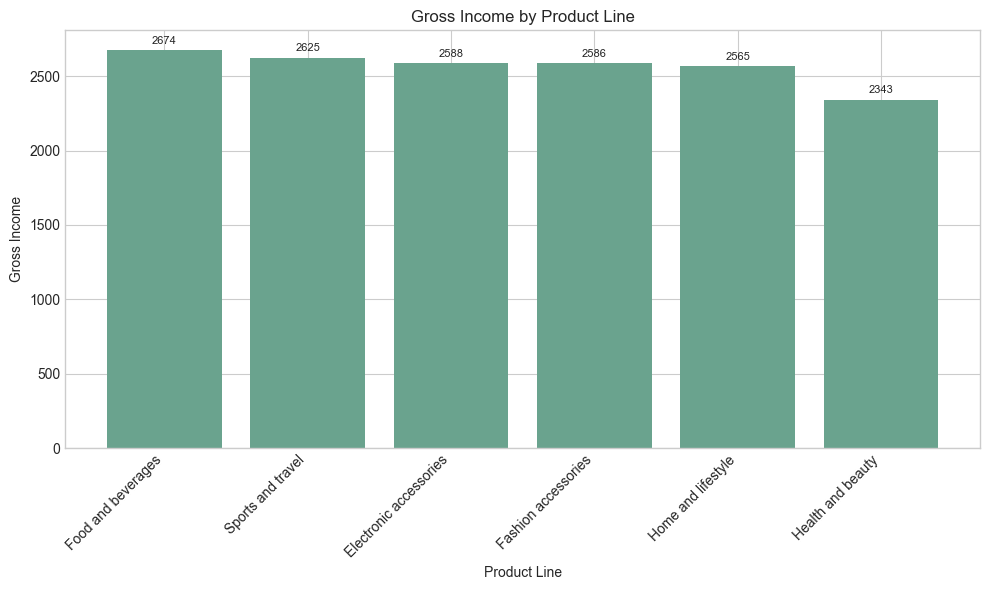

In [16]:
plt.figure(figsize=(10, 6))
bars = plt.bar(
    product_income["product_line"],
    product_income["gross_income"],
    color=secondary_color,
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Product Line")
plt.ylabel("Gross Income")
plt.title("Gross Income by Product Line")
plt.gca().bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()


The gross-income chart broadly follows the sales pattern, which means the leading categories matter not only for revenue but also for income quality.


### 7.3 Sales and Income Quality Analysis

This section compares product-line performance across sales and gross income in order to distinguish between lines that are strong only in revenue terms and lines that are strong in both revenue and income terms.


In [17]:
sales_rank = product_sales.copy()
sales_rank["Sales Rank"] = range(1, len(sales_rank) + 1)

income_rank = product_income.copy()
income_rank["Income Rank"] = range(1, len(income_rank) + 1)

quality_summary = sales_rank.merge(
    income_rank[["product_line", "Income Rank"]],
    on="product_line"
).sort_values(by="Sales Rank")

# Add the "Rank Difference" column to make the comparison more intuitive.
quality_summary["Rank Difference"] = (
    quality_summary["Sales Rank"] - quality_summary["Income Rank"]
).abs()

quality_summary


,product_line,sales,Sales Rank,Income Rank,Rank Difference
0,Food and beverages,"56,144.84",1,1,0
1,Sports and travel,"55,122.83",2,2,0
2,Electronic accessories,"54,337.53",3,3,0
3,Fashion accessories,"54,305.89",4,4,0
4,Home and lifestyle,"53,861.91",5,5,0
5,Health and beauty,"49,193.74",6,6,0


### Interpretation of Product-Line Priorities

Sales and gross income are clearly not spread evenly across product lines. `Food and beverages` ranks first on both measures, making it the strongest line in this dataset. `Sports and travel` and `Electronic accessories` also perform well, so a relatively small group of product lines contributes a large share of supermarket performance.

The ranking comparison adds an important quality check. Lines that remain strong in both sales rank and income rank are more defensible priorities than lines that are strong on sales alone. In the current sample, the leading categories remain broadly consistent across the two measures, which strengthens the case for prioritising them.


### 7.4 Concentration Analysis

Simple ranking shows which product lines come first, but it does not show how concentrated performance is. This section looks at how much of total sales and gross income comes from the top product lines, which helps show whether the supermarket depends heavily on a small set of categories.


In [18]:
top3_sales_share = calculate_top_n_share(product_sales, "sales", n=3)
top_n_sales_share = calculate_top_n_share(product_sales, "sales", n=TOP_N)

top3_income_share = calculate_top_n_share(product_income, "gross_income", n=3)
top_n_income_share = calculate_top_n_share(product_income, "gross_income", n=TOP_N)

concentration_summary = pd.DataFrame({
    "Metric": [
        "Top 3 Share of Total Sales",
        f"Top {TOP_N} Share of Total Sales",
        "Top 3 Share of Gross Income",
        f"Top {TOP_N} Share of Gross Income",
    ],
    "Share": [
        top3_sales_share,
        top_n_sales_share,
        top3_income_share,
        top_n_income_share,
    ],
})

concentration_summary


,Metric,Share
0,Top 3 Share of Total Sales,0.51
1,Top 5 Share of Total Sales,0.85
2,Top 3 Share of Gross Income,0.51
3,Top 5 Share of Gross Income,0.85


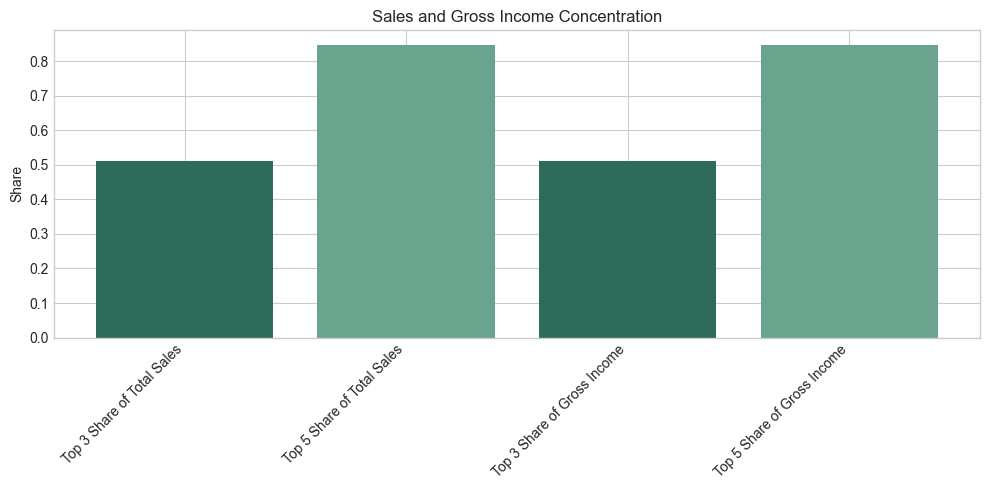

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(
    concentration_summary["Metric"],
    concentration_summary["Share"],
    color=[primary_color, secondary_color, primary_color, secondary_color],
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share")
plt.title("Sales and Gross Income Concentration")
plt.tight_layout()
plt.show()


The concentration chart makes clear that a relatively small set of product lines accounts for a large share of both sales and gross income, so focus and concentration risk need to be considered together.


In [20]:
sales_contribution = product_sales.copy()
sales_contribution["sales_share"] = sales_contribution["sales"] / sales_contribution["sales"].sum()

income_contribution = product_income.copy()
income_contribution["income_share"] = (
    income_contribution["gross_income"] / income_contribution["gross_income"].sum()
)

display(sales_contribution.head(TOP_N))
display(income_contribution.head(TOP_N))


,product_line,sales,sales_share
0,Food and beverages,"56,144.84",0.17
1,Sports and travel,"55,122.83",0.17
2,Electronic accessories,"54,337.53",0.17
3,Fashion accessories,"54,305.89",0.17
4,Home and lifestyle,"53,861.91",0.17


,product_line,gross_income,income_share
0,Food and beverages,"2,673.56",0.17
1,Sports and travel,"2,624.90",0.17
2,Electronic accessories,"2,587.50",0.17
3,Fashion accessories,"2,585.99",0.17
4,Home and lifestyle,"2,564.85",0.17


### Interpretation of Concentration

The concentration results add a clearer structural view of supermarket performance. The top three product lines generate just over half of both total sales and gross income, while the top five account for roughly 85% of both measures in the current sample. This shows that the business is not driven by only one category, but performance is still concentrated in a relatively small set of product lines.

From a managerial point of view, this matters because strong categories deserve attention, but heavy dependence on a small part of the product mix can also create risk. That is why concentration analysis adds more depth than ranking alone.


### 7.5 Branch-Level Performance Analysis

Overall branch totals show whether one branch performs more strongly than another, but they do not explain where that performance comes from. This section compares branches at the overall level, the product-line level, and the within-branch concentration level.


In [21]:
branch_summary = run_branch_analysis(df)
branch_summary["Sales Share (%)"] = branch_summary["sales"] / branch_summary["sales"].sum() * 100

branch_summary


,branch,sales,gross_income,quantity,Sales Share (%)
0,C,"110,568.71","5,265.18",1831,34.24
1,A,"106,200.37","5,057.16",1859,32.88
2,B,"106,197.67","5,057.03",1820,32.88


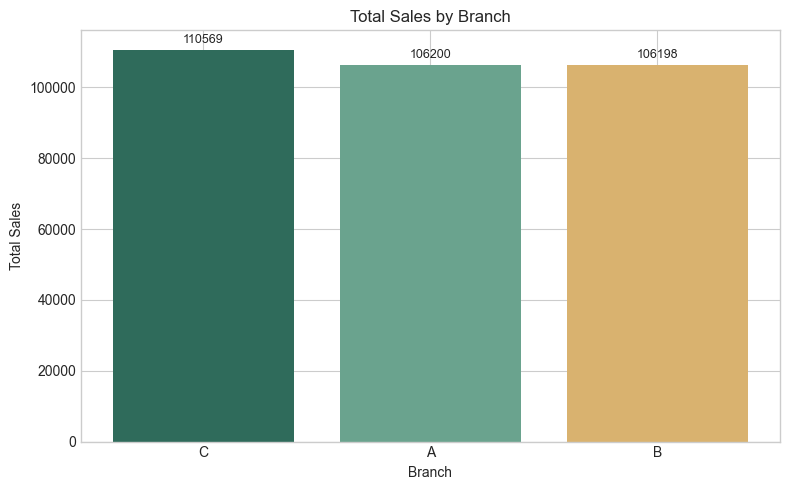

In [22]:
plt.figure(figsize=(8, 5))
bars = plt.bar(branch_summary["branch"], branch_summary["sales"], color=branch_colors)
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.title("Total Sales by Branch")
plt.gca().bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()


Overall branch totals are useful for comparing business scale, but they do not explain which product lines drive each branch. Therefore, the product-line mix still needs to be analysed before making branch-level decisions.

In [23]:
branch_product_sales = (
    df.groupby(["branch", "product_line"], as_index=False)["sales"]
      .sum()
)

branch_product_sales.head()


,branch,product_line,sales
0,A,Electronic accessories,"18,317.11"
1,A,Fashion accessories,"16,332.51"
2,A,Food and beverages,"17,163.10"
3,A,Health and beauty,"12,597.75"
4,A,Home and lifestyle,"22,417.20"


To make branch patterns easier to read, the next table reshapes product-line sales by branch. This makes it easier to see whether the same lines lead across all branches or whether each branch has its own stronger categories.


In [24]:
branch_product_pivot = df.pivot_table(
    values="sales",
    index="product_line",
    columns="branch",
    aggfunc="sum",
)

branch_product_pivot


branch,A,B,C
product_line,,,
Electronic accessories,"18,317.11","17,051.44","18,968.97"
Fashion accessories,"16,332.51","16,413.32","21,560.07"
Food and beverages,"17,163.10","15,214.89","23,766.85"
Health and beauty,"12,597.75","19,980.66","16,615.33"
Home and lifestyle,"22,417.20","17,549.16","13,895.55"
Sports and travel,"19,372.70","19,988.20","15,761.93"


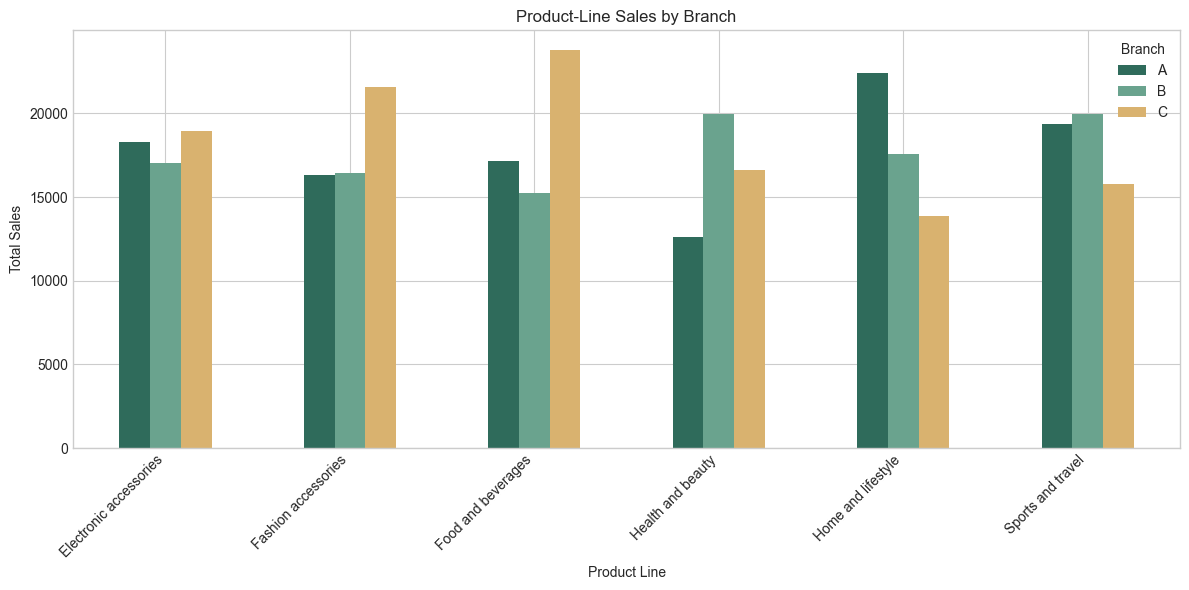

In [25]:
branch_product_pivot.plot(kind="bar", figsize=(12, 6), color=branch_colors)
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.title("Product-Line Sales by Branch")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Branch")
plt.tight_layout()
plt.show()


The grouped bar chart reveals clear differences in product-line performance across branches. For example, `Branch C` leads in `Food and beverages`, while `Branch A` outperforms others in `Home and lifestyle`. These patterns support branch-specific category strategies rather than a one-size-fits-all approach.


In [26]:
branch_top3_sales = (
    branch_product_sales
    .sort_values(["branch", "sales"], ascending=[True, False])
    .groupby("branch")
    .head(3)
)

branch_top3_sales


,branch,product_line,sales
4,A,Home and lifestyle,"22,417.20"
5,A,Sports and travel,"19,372.70"
0,A,Electronic accessories,"18,317.11"
11,B,Sports and travel,"19,988.20"
9,B,Health and beauty,"19,980.66"
10,B,Home and lifestyle,"17,549.16"
14,C,Food and beverages,"23,766.85"
13,C,Fashion accessories,"21,560.07"
12,C,Electronic accessories,"18,968.97"


In [27]:
branch_top3_income = (
    df.groupby(["branch", "product_line"], as_index=False)["gross_income"]
      .sum()
      .sort_values(["branch", "gross_income"], ascending=[True, False])
      .groupby("branch")
      .head(3)
)

branch_top3_income


,branch,product_line,gross_income
4,A,Home and lifestyle,"1,067.49"
5,A,Sports and travel,922.51
0,A,Electronic accessories,872.24
11,B,Sports and travel,951.82
9,B,Health and beauty,951.46
10,B,Home and lifestyle,835.67
14,C,Food and beverages,"1,131.75"
13,C,Fashion accessories,"1,026.67"
12,C,Electronic accessories,903.28


The two top-three tables compare sales priorities and gross-income priorities within each branch. If the same product lines appear in both tables, the branch-level priority is more defensible.

In [28]:
# Calculate the proportion of sales for the top 3 product lines of each branch store
branch_concentration = (
    branch_product_sales
    .sort_values(["branch", "sales"], ascending=[True, False])
)

branch_totals = (
    branch_concentration.groupby("branch", as_index=False)["sales"]
    .sum()
    .rename(columns={"sales": "branch_total"})
)

branch_top3_totals = (
    branch_concentration.groupby("branch")
    .head(3)
    .groupby("branch", as_index=False)["sales"]
    .sum()
    .rename(columns={"sales": "top_3_total"})
)

branch_top3_share = branch_top3_totals.merge(branch_totals, on="branch")
branch_top3_share["Top 3 Sales Share"] = (
    branch_top3_share["top_3_total"] / branch_top3_share["branch_total"]
)
branch_top3_share = branch_top3_share[["branch", "Top 3 Sales Share"]]

branch_top3_share


,branch,Top 3 Sales Share
0,A,0.57
1,B,0.54
2,C,0.58


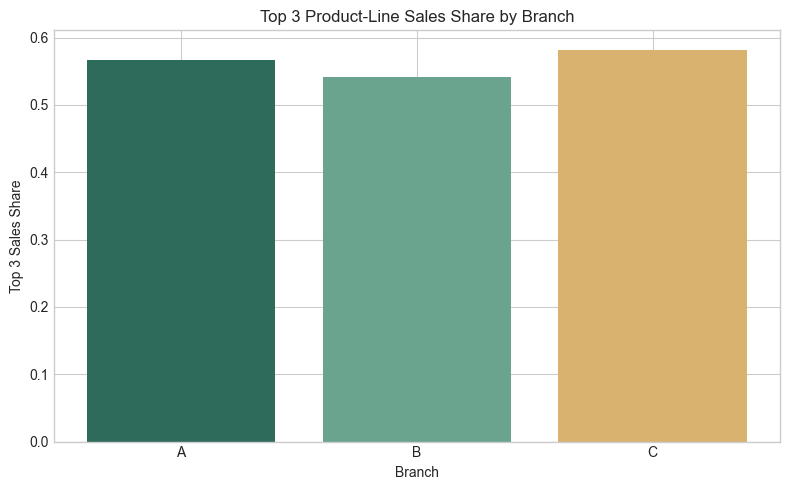

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(branch_top3_share["branch"], branch_top3_share["Top 3 Sales Share"], color=branch_colors)
plt.xlabel("Branch")
plt.ylabel("Top 3 Sales Share")
plt.title("Top 3 Product-Line Sales Share by Branch")
plt.tight_layout()
plt.show()


The chart shows that the top 3 product lines contribute over 50% of sales at every branch, with Branch C having the highest concentration. This means all locations rely heavily on a small number of categories, and each should monitor this dependence to manage risk.


In [30]:
branch_top_pivot = branch_top3_sales.pivot_table(
    values="sales",
    index="product_line",
    columns="branch",
    aggfunc="sum",
)

branch_top_pivot


branch,A,B,C
product_line,,,
Electronic accessories,"18,317.11",NaN,"18,968.97"
Fashion accessories,NaN,NaN,"21,560.07"
Food and beverages,NaN,NaN,"23,766.85"
Health and beauty,NaN,"19,980.66",NaN
Home and lifestyle,"22,417.20","17,549.16",NaN
Sports and travel,"19,372.70","19,988.20",NaN


### Branch-Specific Product Priorities

The branch-level results show that branch strategy should not be based on total sales alone. Branch A is led by `Home and lifestyle`, Branch B by `Sports and travel`, and Branch C by `Food and beverages`, which means the strongest categories are not identical across locations.

The concentration results add another layer to this picture. In each branch, the top three product lines account for roughly 54% to 58% of total branch sales. This means each branch depends meaningfully on a relatively small group of categories, but the exact mix differs by branch. For managers, this supports a combined strategy: keep a few company-wide priorities, but allow branch-level adjustment in stocking and promotion.


### 7.6 Customer Analysis

This section provides a light customer-oriented view of the transaction data. It does not replace customer-level analytics, but it helps managers understand whether different customer-related groups show notable sales or rating differences in the current sample.


In [31]:
customer_summary = run_customer_analysis(df)

# Customer type
if customer_summary is not None:
    customer_type_summary = customer_summary.copy()
    display(customer_type_summary)
else:
    customer_type_summary = pd.DataFrame()
    print("Current input supports customer analysis only lightly because the customer_type field is unavailable.")


,customer_type,average_sales,transaction_count,average_gross_income,average_rating
0,Member,327.79,501,15.61,6.94
1,Normal,318.12,499,15.15,7.01


In [32]:
# Customer gender
if {"gender", "sales", "gross_income", "rating"}.issubset(df.columns):
    gender_summary = (
        df.groupby("gender", as_index=False)[["sales", "gross_income", "rating"]]
          .mean()
    )
else:
    gender_summary = pd.DataFrame()
    print("Current input supports gender-based comparison only lightly because not all required fields are available.")

gender_summary


,gender,sales,gross_income,rating
0,Female,335.10,15.96,6.96
1,Male,310.79,14.80,6.98


In the current sample, customer analysis remains supportive rather than central. Richer customer fields would make this section more decision-relevant.


### 7.7 Time Pattern Analysis

This section explores whether transaction patterns vary across months, weekdays, or time-related dimensions. The current sample covers a relatively short time period, so this section is used for pattern exploration rather than strong long-term seasonal inference.


In [33]:
# Monthly Sales
monthly_sales = (
    df.groupby("month", as_index=False)["sales"]
      .sum()
      .sort_values(by="month")
)

monthly_sales


,month,sales
0,1,"116,291.87"
1,2,"97,219.37"
2,3,"109,455.51"


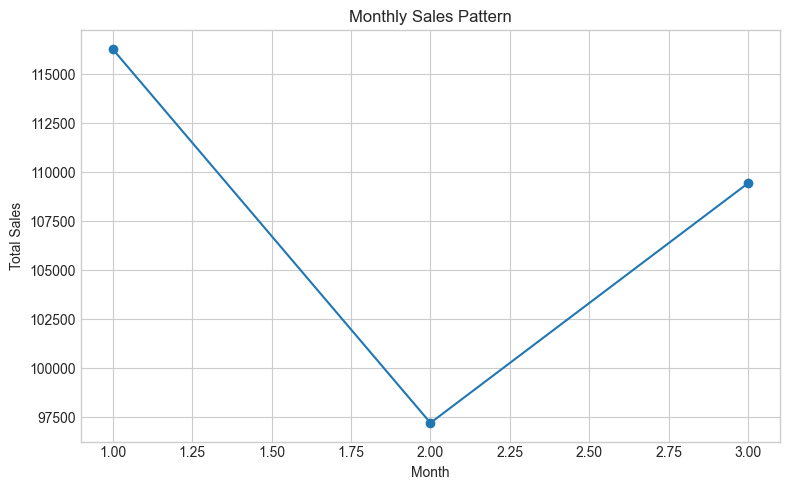

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_sales["month"], monthly_sales["sales"], marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Pattern")
plt.tight_layout()
plt.show()


The line chart shows sales dipped in Month 2 before recovering in Month 3. With only three months of data, this pattern is directional rather than proof of stable seasonality.

In [35]:
# Day of the Week
weekday_sales = run_time_analysis(df)

if weekday_sales is not None:
    weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    weekday_sales["weekday"] = pd.Categorical(
        weekday_sales["weekday"],
        categories=weekday_order,
        ordered=True,
    )
    weekday_sales = weekday_sales.sort_values(by="weekday")
    weekday_sales
else:
    print("No weekday field is available for time pattern analysis.")


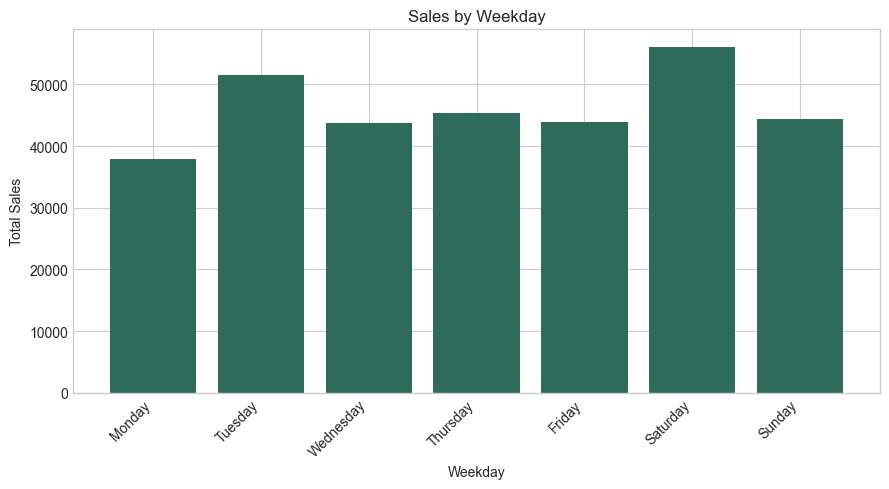

In [36]:
if weekday_sales is not None:
    plt.figure(figsize=(9, 5))
    plt.bar(weekday_sales["weekday"], weekday_sales["sales"], color=primary_color)
    plt.xlabel("Weekday")
    plt.ylabel("Total Sales")
    plt.title("Sales by Weekday")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The chart shows sales peak on Saturdays, while Mondays have the lowest volume. This pattern offers a preliminary view of weekly demand trends.

In [37]:
# Different times of the day
if "part_of_day" in df.columns:
    part_of_day_sales = (
        df.groupby("part_of_day", as_index=False)["sales"]
          .sum()
          .sort_values("sales", ascending=False)
    )
    display(part_of_day_sales)
else:
    part_of_day_sales = pd.DataFrame()
    print("No part_of_day field is available.")

,part_of_day,sales
0,Unknown,"322,966.75"


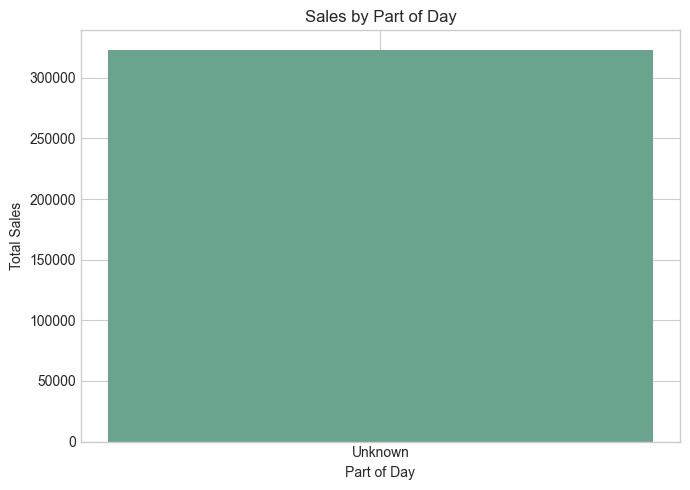

In [38]:
if not part_of_day_sales.empty:
    plt.figure(figsize=(7, 5))
    plt.bar(part_of_day_sales["part_of_day"], part_of_day_sales["sales"], color=secondary_color)
    plt.xlabel("Part of Day")
    plt.ylabel("Total Sales")
    plt.title("Sales by Part of Day")
    plt.tight_layout()
    plt.show()

Time‑of‑day sales patterns cannot be analysed with the current dataset, as the Part of Day field is not available. This feature remains part of the workflow for use with richer datasets.

### 7.8 Relationship Analysis

This section examines selected numeric and categorical relationships in the current sample. The goal is not to claim causality, but to identify whether some transaction-level variables move together in ways that may be managerially relevant.


In [39]:
numeric_candidates = [
    "sales", "gross_income", "quantity", "unit_price",
    "cogs", "rating", "gross_income_ratio",
]

available_numeric = [col for col in numeric_candidates if col in df.columns]

if len(available_numeric) >= 2:
    numeric_corr = df[available_numeric].corr(numeric_only=True)
    display(numeric_corr)

    association_rows = []
    for target_col in ["sales", "gross_income"]:
        if target_col in numeric_corr.columns:
            strongest_match = (
                numeric_corr[target_col]
                .drop(labels=[target_col], errors="ignore")
                .sort_values(ascending=False)
                .head(1)
            )
            if not strongest_match.empty:
                association_rows.append({
                    "target_metric": target_col,
                    "strongest_positive_association": strongest_match.index[0],
                    "correlation_value": strongest_match.iloc[0],
                })

    factor_highlights = pd.DataFrame(association_rows)
    display(factor_highlights)
else:
    numeric_corr = pd.DataFrame()
    factor_highlights = pd.DataFrame()
    print("Not enough numeric fields for correlation analysis.")


,sales,gross_income,quantity,unit_price,cogs,rating,gross_income_ratio
sales,1.00,1.00,0.71,0.63,1.00,-0.04,-0.05
gross_income,1.00,1.00,0.71,0.63,1.00,-0.04,-0.05
quantity,0.71,0.71,1.00,0.01,0.71,-0.02,-0.06
unit_price,0.63,0.63,0.01,1.00,0.63,-0.01,0.01
cogs,1.00,1.00,0.71,0.63,1.00,-0.04,-0.05
rating,-0.04,-0.04,-0.02,-0.01,-0.04,1.00,0.02
gross_income_ratio,-0.05,-0.05,-0.06,0.01,-0.05,0.02,1.00


,target_metric,strongest_positive_association,correlation_value
0,sales,gross_income,1.00
1,gross_income,cogs,1.00


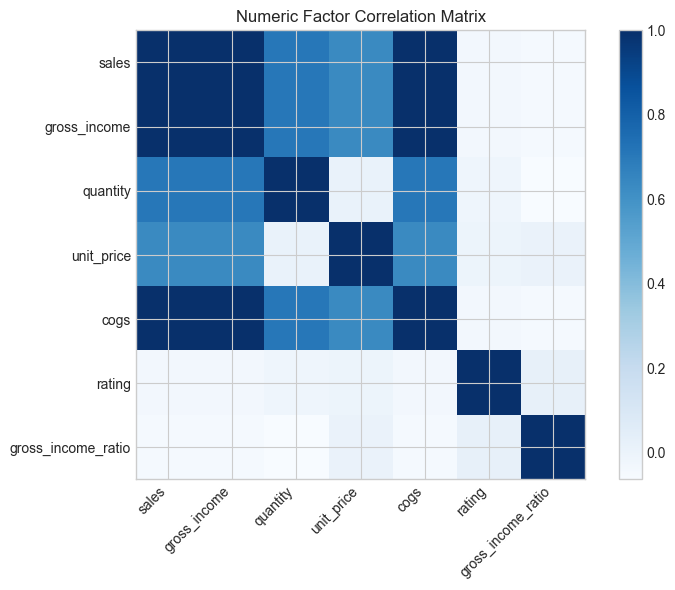

In [40]:
# Create a correlation matrix heatmap
if not numeric_corr.empty:
    plt.figure(figsize=(8, 6))
    plt.imshow(numeric_corr, cmap="Blues", interpolation="nearest")
    plt.xticks(range(len(available_numeric)), available_numeric, rotation=45, ha="right")
    plt.yticks(range(len(available_numeric)), available_numeric)
    plt.colorbar()
    plt.title("Numeric Factor Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Relationship / Factor Analysis is only lightly supported in the current input.")


The numeric factor view highlights which variables move most closely with `sales` and `gross_income` in the sample, but these associations remain descriptive rather than explanatory.

In [41]:
categorical_factors = ["customer_type", "payment", "branch", "product_line"]

categorical_factor_results = {}
for factor in categorical_factors:
    if factor in df.columns and "sales" in df.columns:
        print(f"\nSummary by {factor}:")
        categorical_factor_results[factor] = grouped_factor_summary(df, factor)
        display(categorical_factor_results[factor])



Summary by customer_type:


,customer_type,average_sales,transaction_count,average_gross_income
0,Member,327.79,501,15.61
1,Normal,318.12,499,15.15



Summary by payment:


,payment,average_sales,transaction_count,average_gross_income
0,Cash,326.18,344,15.53
1,Credit card,324.01,311,15.43
2,Ewallet,318.82,345,15.18



Summary by branch:


,branch,average_sales,transaction_count,average_gross_income
0,C,337.10,328,16.05
1,B,319.87,332,15.23
2,A,312.35,340,14.87



Summary by product_line:


,product_line,average_sales,transaction_count,average_gross_income
0,Home and lifestyle,336.64,160,16.03
1,Sports and travel,332.07,166,15.81
2,Health and beauty,323.64,152,15.41
3,Food and beverages,322.67,174,15.37
4,Electronic accessories,319.63,170,15.22
5,Fashion accessories,305.09,178,14.53


The current sample supports relationship analysis, not causal claims. Any managerial interpretation from this section should remain descriptive and cautious.

## 8. Extensible Analysis Design

This notebook is designed as an extensible template rather than a fixed one-off analysis. The current sample activates the core decision-support modules, but richer retail datasets would allow the workflow to expand further.

### Examples of future module extensions
- Promotion / discount analysis
- Inventory-sensitive product prioritisation
- Customer-ID-based repeat purchase analysis
- Foot-traffic and conversion analysis
- Profit-margin analysis
- Supplier and cost-based product strategy analysis

### Current inactive areas
The current sample does not include customer IDs, promotion variables, inventory data, or foot-traffic indicators. As a result, some more advanced retail decision-support modules are not activated in this demonstration.

In [42]:
# Trigger check for expansion module
standardised_columns = set(df.columns)

print("Extensible module trigger check:")

if "discount" in standardised_columns or "promotion_flag" in standardised_columns:
    print("- Promotion module: Activated")
else:
    print("- Promotion module: Skipped because no promotion-related field was found.")

if "inventory_level" in standardised_columns or "stockout_flag" in standardised_columns:
    print("- Inventory module: Activated")
else:
    print("- Inventory module: Skipped because no stock-related field was found.")

if "customer_id" in standardised_columns:
    print("- Repeat-purchase / loyalty module: Activated")
else:
    print("- Repeat-purchase / loyalty module: Skipped because no customer identifier was found.")

if "foot_traffic" in standardised_columns or "store_size" in standardised_columns or "staff_count" in standardised_columns:
    print("- Store-operations module: Activated")
else:
    print("- Store-operations module: Skipped because no store-operation fields were found.")


Extensible module trigger check:
- Promotion module: Skipped because no promotion-related field was found.
- Inventory module: Skipped because no stock-related field was found.
- Repeat-purchase / loyalty module: Skipped because no customer identifier was found.
- Store-operations module: Skipped because no store-operation fields were found.


## 9. Business Insights and Recommendations

The analysis suggests that supermarket managers should evaluate product-line performance using both sales contribution and gross-income contribution, rather than relying on sales alone. In the current sample, `Food and beverages` ranks first on both total sales and gross income, making it the clearest priority product line. `Sports and travel` and `Electronic accessories` also perform strongly, so these categories should receive regular attention in stock planning, display space, and performance monitoring.

The concentration results show that the top three product lines generate just over half of total sales and gross income, while the top five account for roughly 85% of both measures. This means the supermarket is not dependent on only one category, but performance is still concentrated in a relatively small group of product lines. Managers should therefore protect the performance of leading categories while also monitoring concentration risk.

Branch-level results show that a fully uniform category strategy may not be optimal. Branch A is led by `Home and lifestyle`, Branch B by `Sports and travel`, and Branch C by `Food and beverages`. This suggests that managers should combine company-wide product priorities with branch-level adjustments. For example, shared priorities can be maintained for strong overall categories, while each branch should adjust stocking, display, and promotion based on its own strongest product lines.

The customer and time-based analyses should be treated as supporting signals rather than causal evidence. Customer-type, gender, weekday, month, and part-of-day patterns can help managers identify areas for closer monitoring, but they should not be used alone for major decisions. These results are more suitable for guiding follow-up checks, such as whether staffing, replenishment timing, or customer targeting should be reviewed with richer data.

Overall, this notebook supports repeatable decision-making rather than a one-off report. If the supermarket updates its transaction data monthly, the same workflow can be rerun to refresh product-line priorities, branch-level differences, concentration risk, and supporting customer or time patterns. If future datasets include promotions, discounts, inventory levels, customer identifiers, or store-operation variables, the workflow can be extended into deeper operational diagnosis and more targeted managerial actions.

### Recommendation Summary

| Area | Key finding from the sample | Recommended managerial action |
|---|---|---|
| Product-line priority | `Food and beverages` ranks first in both sales and gross income; `Sports and travel` and `Electronic accessories` also perform strongly. | Prioritise these categories in stock planning, display space, and regular performance monitoring. |
| Concentration risk | Top 3 product lines generate just over half of sales and gross income; Top 5 account for roughly 85%. | Protect leading categories, but monitor over-reliance on a limited group of product lines. |
| Branch strategy | Branch A, Branch B, and Branch C have different leading product lines. | Combine company-wide priorities with branch-specific stocking, display, and promotion decisions. |
| Customer and time signals | Customer and time patterns provide useful but descriptive signals. | Use them for follow-up monitoring, not as stand-alone causal evidence. |
| Future workflow use | The notebook can be rerun with updated transaction data. | Use it as a monthly or periodic decision-support workflow. |

## 10. Final Summary

This project used a supermarket transaction dataset as a working sample to demonstrate a reusable and field-aware retail decision-support workflow.

The current sample supports several meaningful analyses, including product-line priorities, branch-level differences, customer-related comparisons, time-based patterns, and selected factor relationships associated with sales and gross income.

The main value of the project is not only the findings from this dataset, but also the structure of the workflow itself. By combining standardised input design, schema detection, feature engineering, modular analysis, and management-oriented output, the notebook is designed to be reused with similar retail datasets.

At the same time, the current analysis should be understood within the limits of the available fields. Stronger operational diagnosis would require richer variables such as promotions, inventory, customer identifiers, and store-operation data.

Overall, the project shows how a transaction dataset can be turned into a clearer, more manager-friendly decision-support workflow, while also remaining extensible for future use.


## 11. Limitations and Future Reuse

### Current Sample Limitations

This project has several clear limitations. First, the dataset covers only a short period, so the time-based results should be treated as short-sample patterns rather than strong evidence of seasonality. Second, the dataset represents one supermarket context, which means the findings should be interpreted cautiously and should not be directly generalised to all retailers.

Third, the notebook is not yet a live reporting pipeline. It still relies on a sample spreadsheet input rather than an automated production data feed. This means the workflow is reusable, but it is not yet fully automated.

Finally, the current sample lacks richer operational fields such as inventory levels, promotion variables, customer IDs, detailed cost information, and foot-traffic measures. As a result, the notebook can support useful descriptive decision support, but it cannot yet provide deeper diagnosis of promotion effectiveness, stockout risk, repeat purchase behaviour, or store-operation efficiency.

### Future Reuse

The workflow is designed for future reuse with other structured retail inputs, including POS exports, CSV sales logs, ERP reports, and database extracts. Because the notebook uses field standardisation, schema detection, feature engineering, and reusable analysis functions, it can be rerun with similar transaction datasets after updating the input file and field mapping.

With clearer field mapping and richer variables, the same template could support deeper analysis of promotion effects, margin quality, repeat purchase behaviour, inventory-sensitive prioritisation, and longer-term time patterns. In other words, the current notebook is a reusable starting point, but stronger input fields would improve the depth, reliability, and managerial usefulness of the resulting insights.